Expanded Stock Prediction ML Project ( RandomForestClassifier vs Logistic Regression )

In [27]:
%pip install yfinance

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 21.5 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15702 sha256=6b9ced0e656cdbdb86242e26314070514e67cc6624bfa2d05fa8487d39bd0266
  Stored in directory: c:\users\annik\appdata\local\pip\cache\wheels\42\d6\84\bf57a755f4569494cd00de4bb46ef064874823f4d19c82e960
Successfully built multitasking

   ----------------------------------------  0/16 [peewee]
   ----------------------------------------  0/16 [peewee]
   ----------------------------------------  0/16 [peewee]
   ----- ----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import pandas as pd

stonks = pd.read_csv("../datasets/global_stocks_indice.csv")
stonks.head()

,Date,Open,High,Low,Close,Volume,Ticker,Index_Name
0,2000-01-03,1469.250000,1478.000000,1438.359985,1455.219971,931800000,^GSPC,S&P 500 (USA)
1,2000-01-04,1455.219971,1455.219971,1397.430054,1399.420044,1009000000,^GSPC,S&P 500 (USA)
2,2000-01-05,1399.420044,1413.270020,1377.680054,1402.109985,1085500000,^GSPC,S&P 500 (USA)
3,2000-01-06,1402.109985,1411.900024,1392.099976,1403.449951,1092300000,^GSPC,S&P 500 (USA)
4,2000-01-07,1403.449951,1441.469971,1400.729980,1441.469971,1225200000,^GSPC,S&P 500 (USA)


In [ ]:
stonks["Index_Name"].value_counts()

Index_Name
CAC 40 (France)          6704
DAX (Germany)            6660
ASX 200 (Australia)      6627
FTSE 100 (UK)            6626
S&P 500 (USA)            6596
Dow Jones (USA)          6596
NASDAQ (USA)             6596
TSX (Canada)             6588
Bovespa (Brazil)         6498
BSE Sensex (India)       6467
Hang Seng (Hong Kong)    6462
KOSPI (South Korea)      6458
Nikkei 225 (Japan)       6423
SSE Composite (China)    6347
Name: count, dtype: int64

: 

In [25]:
stonks["Ticker"].value_counts()

Ticker
^FCHI        6704
^GDAXI       6660
^AXJO        6627
^FTSE        6626
^GSPC        6596
^DJI         6596
^IXIC        6596
^GSPTSE      6588
^BVSP        6498
^BSESN       6467
^HSI         6462
^KS11        6458
^N225        6423
000001.SS    6347
Name: count, dtype: int64

In [2]:
import yfinance as yf

In [3]:
sp500 = yf.download("^GSPC", start="2010-01-01", end="2026-01-01")
dax = yf.download("^GDAXI", start="2010-01-01", end="2026-01-01")
cac40 = yf.download("^FCHI", start="2010-01-01", end="2026-01-01")
asx200 = yf.download("^AXJO", start="2010-01-01", end="2026-01-01")
ftse100 = yf.download("^FTSE", start="2010-01-01", end="2026-01-01")
dowjones = yf.download("^DJI", start="2010-01-01", end="2026-01-01")
nasdaq = yf.download("^IXIC", start="2010-01-01", end="2026-01-01")
tsx = yf.download("^GSPTSE", start="2010-01-01", end="2026-01-01")
bovespa = yf.download("^BVSP", start="2010-01-01", end="2026-01-01")
bse_sensex = yf.download("^BSESN", start="2010-01-01", end="2026-01-01")
hangseng = yf.download("^HSI", start="2010-01-01", end="2026-01-01")
kospi = yf.download("^KS11", start="2010-01-01", end="2026-01-01")
nikkei225 = yf.download("^N225", start="2010-01-01", end="2026-01-01")
sse_composite = yf.download("000001.SS", start="2010-01-01", end="2026-01-01")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [7]:
sp500

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2010-01-04,1132.989990,1133.869995,1116.560059,1116.560059,3991400000
2010-01-05,1136.520020,1136.630005,1129.660034,1132.660034,2491020000
2010-01-06,1137.140015,1139.189941,1133.949951,1135.709961,4972660000
2010-01-07,1141.689941,1142.459961,1131.319946,1136.270020,5270680000
2010-01-08,1144.979980,1145.390015,1136.219971,1140.520020,4389590000
...,...,...,...,...,...
2025-12-24,6932.049805,6937.319824,6904.910156,6904.910156,1798270000
2025-12-26,6929.939941,6945.770020,6921.600098,6936.020020,2586550000


<Axes: title={'center': 'S&P 500 Closing Price'}, xlabel='Date'>

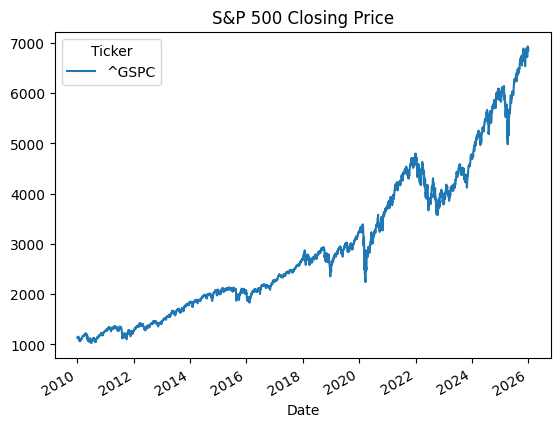

In [10]:
sp500.plot.line(y="Close", title="S&P 500 Closing Price", use_index=True)